In [14]:
# %%
# ── Cell 1: Imports & Config ───────────────────────────────────────────────────
import torch
import torchvision.transforms as transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

DEVICE = torch.device("cpu")

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

MODEL_DIR  = "quantized_models"
DATA_DIR   = "../data_test/"

ENGINE_MAP = {
    "resnet50_dynamic.pt"           : "onednn",
    "resnet50_static_minmax.pt"     : "onednn",
    "resnet50_static_moving_avg.pt" : "onednn",
    "resnet50_static_histogram.pt"  : "onednn",
    "resnet50_static_percentile.pt" : "onednn",
    "resnet50_fx_x86.pt"            : "x86",
    "resnet50_fx_fbgemm.pt"         : "fbgemm",
}

print(f"Using device : {DEVICE}")
print(f"Model dir    : {MODEL_DIR}")
print(f"Data dir     : {DATA_DIR}")

Using device : cpu
Model dir    : quantized_models
Data dir     : ../data_test/


In [15]:
# %%
# ── Cell 2: Transform ─────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

print("✓ Transform ready")

✓ Transform ready


In [16]:
# %%
# ── Cell 3 (replace): Load Model — robust version ─────────────────────────────
import copy
import torch.quantization as tq
from torch.ao.quantization import get_default_qconfig, QConfig
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx
import torchvision.models as models
import torch.nn as nn

CALIB_SIZE   = 1024
CALIB_BATCHES = 8
CIFAR_MEAN   = (0.4914, 0.4822, 0.4465)
CIFAR_STD    = (0.2023, 0.1994, 0.2010)

OBSERVER_QCONFIGS = {
    "minmax": QConfig(
        activation=tq.MinMaxObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_affine),
        weight=tq.PerChannelMinMaxObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
    ),
    "moving_avg": QConfig(
        activation=tq.MovingAverageMinMaxObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_affine),
        weight=tq.MovingAveragePerChannelMinMaxObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
    ),
    "histogram": QConfig(
        activation=tq.HistogramObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_affine),
        weight=tq.PerChannelMinMaxObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
    ),
    "percentile": QConfig(
        activation=tq.HistogramObserver.with_args(
            dtype=torch.quint8, qscheme=torch.per_tensor_affine,
            reduce_range=True),
        weight=tq.PerChannelMinMaxObserver.with_args(
            dtype=torch.qint8, qscheme=torch.per_channel_symmetric),
    ),
}

def build_fp32_model():
    model = models.resnet50(weights=None)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(model.fc.in_features, 10)
    return model

def get_calib_loader():
    import torchvision
    from torch.utils.data import DataLoader, Subset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    ])
    ds  = torchvision.datasets.CIFAR10(root="../../data", train=True,
                                        download=True, transform=transform)
    sub = Subset(ds, list(range(CALIB_SIZE)))
    return DataLoader(sub, batch_size=128, shuffle=False, num_workers=2)

@torch.no_grad()
def calibrate(model, loader, max_batches=CALIB_BATCHES):
    model.eval()
    for i, (inputs, _) in enumerate(loader):
        model(inputs)
        if i + 1 >= max_batches:
            break

def load_model(model_path: str):
    """
    Robust loader — rebuilds quantized model from fp32 weights + recipe
    instead of deserializing the full quantized object (which breaks across
    PyTorch versions due to ConvReLU2d / FX graph serialization bugs).
    """
    filename = os.path.basename(model_path)
    example  = torch.randn(1, 3, 32, 32)

    # ── Dynamic ───────────────────────────────────────────────────────────────
    if filename == "resnet50_dynamic.pt":
        torch.backends.quantized.engine = "onednn"
        fp32 = build_fp32_model()
        fp32.load_state_dict(torch.load(
            "../__2__baseline_resnet50_cifar10.pth", map_location="cpu"))
        model = torch.quantization.quantize_dynamic(
            fp32.eval(), {nn.Linear}, dtype=torch.qint8)
        print(f"  ✓ Loaded  : {filename}  (dynamic, engine=onednn)")
        return model.eval()

    # ── Static FX — observer sweep ────────────────────────────────────────────
    for obs_name, qconfig in OBSERVER_QCONFIGS.items():
        if filename == f"resnet50_static_{obs_name}.pt":
            torch.backends.quantized.engine = "onednn"
            fp32     = build_fp32_model()
            fp32.load_state_dict(torch.load(
                "../__2__baseline_resnet50_cifar10.pth", map_location="cpu"))
            prepared = prepare_fx(fp32.eval(), {"": qconfig}, example)
            calibrate(prepared, get_calib_loader())
            model    = convert_fx(prepared)
            print(f"  ✓ Loaded  : {filename}  (static_fx/{obs_name}, engine=onednn)")
            return model.eval()

    # ── FX default backends ───────────────────────────────────────────────────
    for backend in ["x86", "fbgemm"]:
        if filename == f"resnet50_fx_{backend}.pt":
            torch.backends.quantized.engine = backend
            fp32     = build_fp32_model()
            fp32.load_state_dict(torch.load(
                "../__2__baseline_resnet50_cifar10.pth", map_location="cpu"))
            prepared = prepare_fx(fp32.eval(),
                                  {"": get_default_qconfig(backend)}, example)
            calibrate(prepared, get_calib_loader())
            model    = convert_fx(prepared)
            print(f"  ✓ Loaded  : {filename}  (fx_static/{backend})")
            return model.eval()

    raise ValueError(f"Unknown model filename: {filename}")

print("✓ load_model() ready")

✓ load_model() ready


In [17]:
# %%
# ── Cell 4: Predict Functions ─────────────────────────────────────────────────
def predict_image(image_path: str, model, show: bool = True):
    img = Image.open(image_path).convert("RGB")
    x   = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(x)
        probs   = torch.softmax(outputs, dim=1).squeeze().cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred     = CIFAR10_CLASSES[pred_idx]
    conf     = float(probs[pred_idx])

    print(f"  {os.path.basename(image_path):30s} → {pred:12s} ({conf:.2%})")

    if show:
        plt.imshow(img)
        plt.title(f"{pred} ({conf:.2%})")
        plt.axis("off")
        plt.show()

    return pred, probs


def predict_folder(folder: str, model, show: bool = False):
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")

    files = [f for f in os.listdir(folder)
             if f.lower().endswith((".jpg", ".png", ".jpeg", ".bmp", ".webp"))]

    if not files:
        print("  No images found.")
        return

    for f in sorted(files):
        predict_image(os.path.join(folder, f), model, show=show)

print("✓ Predict functions ready")

✓ Predict functions ready


In [ ]:
# ── Cell 5: Test a Single Model ───────────────────────────────────────────────
MODEL_PATH = os.path.join(MODEL_DIR, "resnet50_dynamic.pt")

model = load_model(MODEL_PATH)
predict_folder(DATA_DIR, model)
print("\nDone.")

C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:85: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(


  ✓ Loaded  : resnet50_dynamic.pt  (dynamic, engine=onednn)
  airplane1.png                  → airplane     (90.86%)
  airplane2.png                  → airplane     (90.04%)
  airplane3.png                  → airplane     (90.17%)
  airplane4.png                  → airplane     (91.06%)
  airplane5.png                  → airplane     (92.60%)
  airplane6.png                  → airplane     (91.74%)
  automobile1.png                → automobile   (90.29%)
  automobile2.png                → automobile   (88.11%)
  automobile4.png                → automobile   (91.25%)
  automobile5.png                → automobile   (95.01%)
  automobile6.png                → automobile   (93.49%)
  bird1.png                      → bird         (87.41%)
  bird2.png                      → bird         (59.21%)
  bird3.png                      → bird         (87.12%)
  bird5.png                      → bird         (91.45%)
  bird6.png                      → bird         (92.04%)
  cat1.png                  

In [20]:
# %%
# ── Cell 6: Test ALL Models ───────────────────────────────────────────────────
results_summary = {}

for filename in sorted(os.listdir(MODEL_DIR)):
    if not filename.endswith(".pt"):
        continue

    path = os.path.join(MODEL_DIR, filename)
    print(f"\n{'─'*55}")
    print(f"  Model: {filename}")
    print(f"{'─'*55}")

    try:
        model = load_model(path)
        predict_folder(DATA_DIR, model, show=False)
        results_summary[filename] = "✓ OK"
    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        results_summary[filename] = f"✗ {e}"

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  Summary")
print(f"{'='*55}")
for name, status in results_summary.items():
    print(f"  {name:45s} {status}")
print(f"{'='*55}")


───────────────────────────────────────────────────────
  Model: resnet50_dynamic.pt
───────────────────────────────────────────────────────


C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:85: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model = torch.quantization.quantize_dynamic(


  ✓ Loaded  : resnet50_dynamic.pt  (dynamic, engine=onednn)
  airplane1.png                  → airplane     (90.86%)
  airplane2.png                  → airplane     (90.04%)
  airplane3.png                  → airplane     (90.17%)
  airplane4.png                  → airplane     (91.06%)
  airplane5.png                  → airplane     (92.60%)
  airplane6.png                  → airplane     (91.74%)
  automobile1.png                → automobile   (90.29%)
  automobile2.png                → automobile   (88.11%)
  automobile4.png                → automobile   (91.25%)
  automobile5.png                → automobile   (95.01%)
  automobile6.png                → automobile   (93.49%)
  bird1.png                      → bird         (87.41%)
  bird2.png                      → bird         (59.21%)
  bird3.png                      → bird         (87.12%)
  bird5.png                      → bird         (91.45%)
  bird6.png                      → bird         (92.04%)
  cat1.png                  

C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:97: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare_fx(fp32.eval(), {"": qconfig}, example)
e:\baseline_resnet50_cifar10\env\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported

  ✓ Loaded  : resnet50_static_histogram.pt  (static_fx/histogram, engine=onednn)
  airplane1.png                  → airplane     (90.70%)
  airplane2.png                  → airplane     (89.84%)
  airplane3.png                  → airplane     (90.11%)
  airplane4.png                  → airplane     (91.27%)
  airplane5.png                  → airplane     (92.54%)
  airplane6.png                  → airplane     (91.61%)
  automobile1.png                → automobile   (90.23%)
  automobile2.png                → automobile   (86.58%)
  automobile4.png                → automobile   (91.14%)
  automobile5.png                → automobile   (95.26%)
  automobile6.png                → automobile   (93.49%)
  bird1.png                      → bird         (87.82%)
  bird2.png                      → bird         (57.78%)
  bird3.png                      → bird         (87.06%)
  bird5.png                      → bird         (91.92%)
  bird6.png                      → bird         (92.08%)
  cat1.

...

  ✓ Loaded  : resnet50_static_minmax.pt  (static_fx/minmax, engine=onednn)
  airplane1.png                  → airplane     (91.25%)
  airplane2.png                  → airplane     (89.82%)
  airplane3.png                  → airplane     (90.37%)
  airplane4.png                  → airplane     (91.02%)
  airplane5.png                  → airplane     (92.62%)
  airplane6.png                  → airplane     (91.65%)
  automobile1.png                → automobile   (90.60%)
  automobile2.png                → automobile   (88.10%)
  automobile4.png                → automobile   (91.22%)
  automobile5.png                → automobile   (95.68%)
  automobile6.png                → automobile   (93.69%)
  bird1.png                      → bird         (88.44%)
  bird2.png                      → bird         (63.57%)
  bird3.png                      → bird         (87.89%)
  bird5.png                      → bird         (91.44%)
  bird6.png                      → bird         (92.37%)
  cat1.png   

C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:97: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare_fx(fp32.eval(), {"": qconfig}, example)
e:\baseline_resnet50_cifar10\env\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported

  ✓ Loaded  : resnet50_static_moving_avg.pt  (static_fx/moving_avg, engine=onednn)
  airplane1.png                  → airplane     (91.20%)
  airplane2.png                  → airplane     (89.82%)
  airplane3.png                  → airplane     (90.52%)
  airplane4.png                  → airplane     (91.02%)
  airplane5.png                  → airplane     (92.52%)
  airplane6.png                  → airplane     (91.78%)
  automobile1.png                → automobile   (90.46%)
  automobile2.png                → automobile   (88.09%)
  automobile4.png                → automobile   (91.17%)
  automobile5.png                → automobile   (95.27%)
  automobile6.png                → automobile   (93.38%)
  bird1.png                      → bird         (87.51%)
  bird2.png                      → bird         (66.00%)
  bird3.png                      → bird         (87.00%)
  bird5.png                      → bird         (91.38%)
  bird6.png                      → bird         (92.00%)
  cat

C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:97: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare_fx(fp32.eval(), {"": qconfig}, example)
e:\baseline_resnet50_cifar10\env\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported

  ✓ Loaded  : resnet50_static_percentile.pt  (static_fx/percentile, engine=onednn)
  airplane1.png                  → airplane     (90.81%)
  airplane2.png                  → airplane     (90.17%)
  airplane3.png                  → airplane     (90.23%)
  airplane4.png                  → airplane     (90.14%)
  airplane5.png                  → airplane     (92.63%)
  airplane6.png                  → airplane     (91.75%)
  automobile1.png                → automobile   (90.67%)
  automobile2.png                → automobile   (88.69%)
  automobile4.png                → automobile   (91.32%)
  automobile5.png                → automobile   (95.33%)
  automobile6.png                → automobile   (93.45%)
  bird1.png                      → bird         (88.29%)
  bird2.png                      → bird         (47.55%)
  bird3.png                      → bird         (86.29%)
  bird5.png                      → bird         (92.27%)
  bird6.png                      → bird         (92.24%)
  cat

C:\Users\Mohammed Elidrissi\AppData\Local\Temp\ipykernel_28656\3341541681.py:97: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared = prepare_fx(fp32.eval(), {"": qconfig}, example)
e:\baseline_resnet50_cifar10\env\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported

  ✓ Loaded  : resnet50_static_minmax.pt  (static_fx/minmax, engine=onednn)


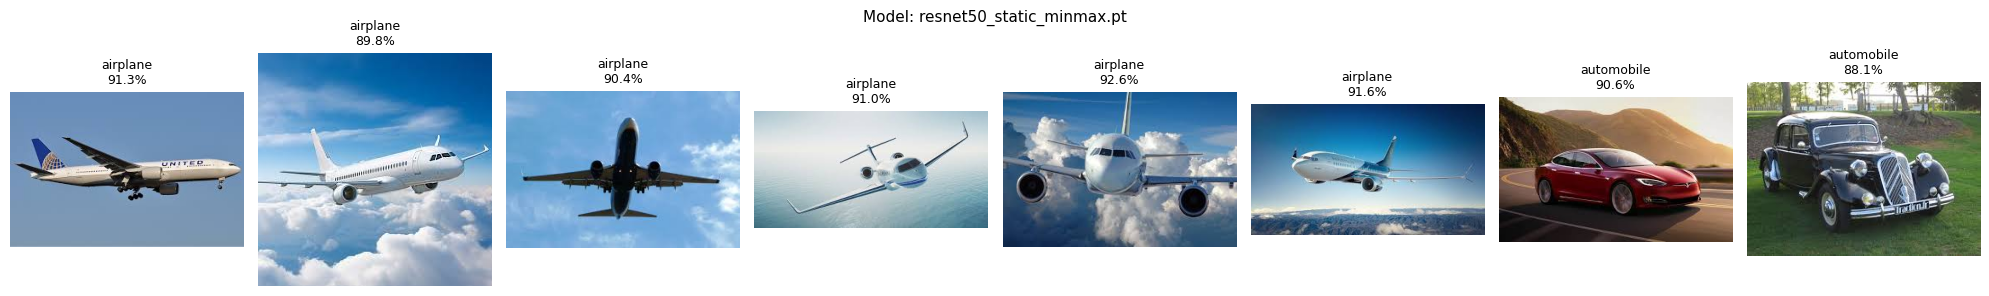

In [21]:
# %%
# ── Cell 7: Visualize Predictions for One Model ───────────────────────────────
# Shows images with predictions — pick any model you want to inspect visually

MODEL_PATH = os.path.join(MODEL_DIR, "resnet50_static_minmax.pt")
model      = load_model(MODEL_PATH)

files = [f for f in os.listdir(DATA_DIR)
         if f.lower().endswith((".jpg", ".png", ".jpeg", ".bmp", ".webp"))]

fig, axes = plt.subplots(1, min(len(files), 8), figsize=(20, 3))
if len(files) == 1:
    axes = [axes]

for ax, fname in zip(axes, sorted(files)[:8]):
    img  = Image.open(os.path.join(DATA_DIR, fname)).convert("RGB")
    x    = transform(img).unsqueeze(0)
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1).squeeze().numpy()
    pred = CIFAR10_CLASSES[int(np.argmax(probs))]
    conf = float(probs[int(np.argmax(probs))])

    ax.imshow(img)
    ax.set_title(f"{pred}\n{conf:.1%}", fontsize=9)
    ax.axis("off")

plt.suptitle(f"Model: {os.path.basename(MODEL_PATH)}", fontsize=11)
plt.tight_layout()
plt.show()